In [3]:
%pip install scikit-learn --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


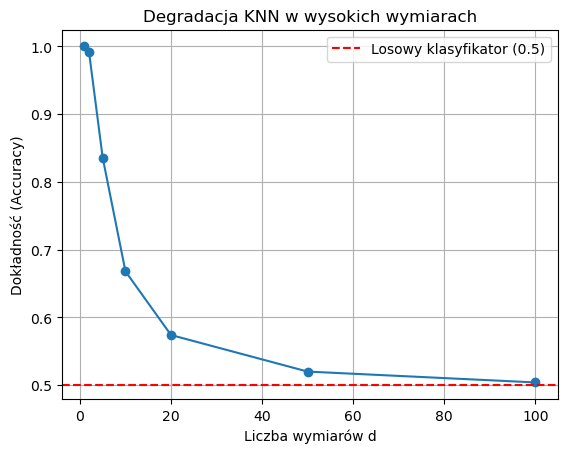

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
n_train = 1000
n_test = 500
dokladnosc = []
wymiary=[1,2,5,10,20,50,100]
for d in wymiary:
    X_train=np.random.normal(0,1,(n_train,d))
    X_test=np.random.normal(0,1,(n_test,d))
    normy_train=np.linalg.norm(X_train,axis=1)
    rd=np.median(normy_train)
    y_train=(normy_train<=rd).astype(int)
    
    normy_test=np.linalg.norm(X_test,axis=1)
    y_test=(normy_test<=rd).astype(int)

    knn=KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    dokladnosc.append(acc)


plt.plot(wymiary, dokladnosc, marker='o')
plt.xlabel('Liczba wymiarów d')
plt.ylabel('Dokładność (Accuracy)')
plt.title('Degradacja KNN w wysokich wymiarach')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', label='Losowy klasyfikator (0.5)') # Dodaje czerwoną linię na poziomie 50%
plt.legend()
plt.show()